In [2]:
import torch

from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection
)

In [3]:
MODEL_NAME = "facebook/detr-resnet-50"

print("Model:", MODEL_NAME)

Model: facebook/detr-resnet-50


In [4]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

print("Image processor loaded successfully")

Image processor loaded successfully


In [5]:
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME
)

print("Model loaded successfully")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [6]:
print(model)

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvEncoder(
      (model): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): DetrFrozenBatchNorm2d()
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): DetrFrozenBatchNorm2d()
            (drop_block): Identity()
            (act2): ReLU(inplace=True)
            (aa): Identity()
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): DetrFrozenBatchNorm2d()
            (act3): ReLU(inplace

In [7]:
print("Architecture:", model.config.model_type)
print("Number of labels:", model.config.num_labels)

print("\nFirst few labels:")

for label_id, label_name in list(model.config.id2label.items())[:10]:
    print(label_id, "->", label_name)

Architecture: detr
Number of labels: 91

First few labels:
0 -> N/A
1 -> person
10 -> traffic light
11 -> fire hydrant
12 -> street sign
13 -> stop sign
14 -> parking meter
15 -> bench
16 -> bird
17 -> cat


In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [9]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [10]:
image = Image.open("../images/road.jpg").convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (500, 334)
Image mode: RGB


In [11]:
inputs = processor(
    images=image,
    return_tensors="pt"
)

In [12]:
print(inputs)

{'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[ 1.4612,  1.4440,  1.4098,  ...,  0.5364,  0.4166,  0.3823],
          [ 1.5125,  1.4612,  1.3755,  ...,  0.5707,  0.3994,  0.3481],
          [ 1.6495,  1.5468,  1.2385,  ...,  0.6734,  0.3309,  0.2282],
          ...,
          [-0.4226, -0.4226, -0.4226,  ..., -0.2342, -0.2342, -0.2342],
          [-0.4226, -0.4226, -0.4226,  ..., -0.2513, -0.2513, -0.2513],
          [-0.4226, -0.4226, -0.4226,  ..., -0.2513, -0.2513, -0.2513]],

         [[ 0.8529,  0.8354,  0.8004,  ..., -0.2850, -0.4076, -0.4426],
          [ 0.9055,  0.8529,  0.7654,  ..., -0.2500, -0.4426, -0.4776],
          [ 1.0455,  0.9405,  0.6254,  ..., -0.1625, -0.5301, -0.6176],
          ...,
          [-0.4076, -0.4076, -0.4076,  ..., -0.4426, -0.4426, 

In [13]:
pixel_values = inputs["pixel_values"]

print("Type:", type(pixel_values))
print("Shape:", pixel_values.shape)
print("Data type:", pixel_values.dtype)

Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 3, 800, 1197])
Data type: torch.float32


In [14]:
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

print("Inputs moved to:", device)

Inputs moved to: cpu


In [15]:
with torch.inference_mode():
    outputs = model(**inputs)

In [16]:
print(type(outputs))
print(outputs)

<class 'transformers.models.detr.modeling_detr.DetrObjectDetectionOutput'>
DetrObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-13.5236,   5.8233,   1.5541,  ...,  -7.7779,  -5.1390,   6.2488],
         [-13.9639,   7.0151,   0.9776,  ..., -11.7633,  -6.2745,   6.5015],
         [-12.6025,   4.1798,  -1.7827,  ...,  -8.1191,  -7.4150,   6.7242],
         ...,
         [-13.4564,   4.1347,  -2.6139,  ..., -11.5469,  -6.7329,   6.5242],
         [-11.8886,   2.4093,  -2.6727,  ..., -11.7883,  -8.3974,   5.6630],
         [-13.7158,   4.9184,  -0.8159,  ..., -12.3331,  -7.7331,   6.7108]]]), pred_boxes=tensor([[[0.0626, 0.6048, 0.0292, 0.1244],
         [0.4950, 0.5531, 0.0166, 0.0495],
         [0.1590, 0.6018, 0.0784, 0.1141],
         [0.5090, 0.5201, 0.0214, 0.0257],
         [0.4566, 0.5259, 0.0212, 0.0254],
         [0.5121, 0.5646, 0.0615, 0.0854],
         [0.4840, 0.5574, 0.0196, 0.0597],
         [0.3558, 0.5625, 0.0155, 0.0591],
         [0.2412, 0.5419, 0.021

In [17]:
print("Output type:", type(outputs))

print("\nAvailable output fields:")
print(outputs.keys())

Output type: <class 'transformers.models.detr.modeling_detr.DetrObjectDetectionOutput'>

Available output fields:
odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])


In [18]:
print("Logits shape:")
print(outputs.logits.shape)

Logits shape:
torch.Size([1, 100, 92])


In [19]:
print("Predicted box shape:")
print(outputs.pred_boxes.shape)

Predicted box shape:
torch.Size([1, 100, 4])


In [20]:
target_sizes = torch.tensor(
    [image.size[::-1]],
    device=device
)

print("Target size:", target_sizes)

Target size: tensor([[334, 500]])


In [21]:
processed_results = processor.post_process_object_detection(
    outputs,
    target_sizes=target_sizes,
    threshold=0.5
)

In [22]:
result = processed_results[0]

print(result.keys())

dict_keys(['scores', 'labels', 'boxes'])


In [23]:
print("Score shape:", result["scores"].shape)
print("Labels shape:", result["labels"].shape)
print("Boxes shape:", result["boxes"].shape)

Score shape: torch.Size([50])
Labels shape: torch.Size([50])
Boxes shape: torch.Size([50, 4])


In [24]:
scores = result["scores"]
labels = result["labels"]
boxes = result["boxes"]

for score, label_id, box in zip(scores, labels, boxes):
    label_name = model.config.id2label[label_id.item()]

    print(
        f"{label_name:12s} "
        f"score={score.item():.3f} "
        f"box={box.tolist()}"
    )

person       score=0.550 box=[243.3289031982422, 176.46177673339844, 251.63018798828125, 192.98162841796875]
car          score=0.683 box=[222.99053955078125, 171.41810607910156, 233.60618591308594, 179.91470336914062]
person       score=0.711 box=[237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]
person       score=0.810 box=[419.6012268066406, 178.13890075683594, 432.9241943359375, 216.2056884765625]
person       score=0.559 box=[39.66762161254883, 173.23582458496094, 54.56563949584961, 221.84933471679688]
person       score=0.768 box=[409.7339782714844, 178.51080322265625, 422.407958984375, 215.01991271972656]
truck        score=0.713 box=[344.268310546875, 171.84300231933594, 406.4440612792969, 243.4425506591797]
person       score=0.654 box=[404.0029602050781, 178.7337646484375, 416.21630859375, 214.98451232910156]
car          score=0.947 box=[477.89654541015625, 183.05799865722656, 499.97882080078125, 230.21435546875]
person       score=0.765 box=[462.765

In [25]:
detections = []

for score, label_id, box in zip(scores, labels, boxes):
    label_name = model.config.id2label[label_id.item()]

    xmin, ymin, xmax, ymax = box.tolist()

    detections.append({
        "label": label_name,
        "score": float(score),
        "box": {
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        }
    })

print(f"Total detections: {len(detections)}")

for detection in detections:
    print(detection)

Total detections: 50
{'label': 'person', 'score': 0.5495909452438354, 'box': {'xmin': 243.3289031982422, 'ymin': 176.46177673339844, 'xmax': 251.63018798828125, 'ymax': 192.98162841796875}}
{'label': 'car', 'score': 0.6830475926399231, 'box': {'xmin': 222.99053955078125, 'ymin': 171.41810607910156, 'xmax': 233.60618591308594, 'ymax': 179.91470336914062}}
{'label': 'person', 'score': 0.7110489010810852, 'box': {'xmin': 237.0771484375, 'ymin': 176.21646118164062, 'xmax': 246.900146484375, 'ymax': 196.15638732910156}}
{'label': 'person', 'score': 0.8095473051071167, 'box': {'xmin': 419.6012268066406, 'ymin': 178.13890075683594, 'xmax': 432.9241943359375, 'ymax': 216.2056884765625}}
{'label': 'person', 'score': 0.5590566992759705, 'box': {'xmin': 39.66762161254883, 'ymin': 173.23582458496094, 'xmax': 54.56563949584961, 'ymax': 221.84933471679688}}
{'label': 'person', 'score': 0.7682541608810425, 'box': {'xmin': 409.7339782714844, 'ymin': 178.51080322265625, 'xmax': 422.407958984375, 'ymax'

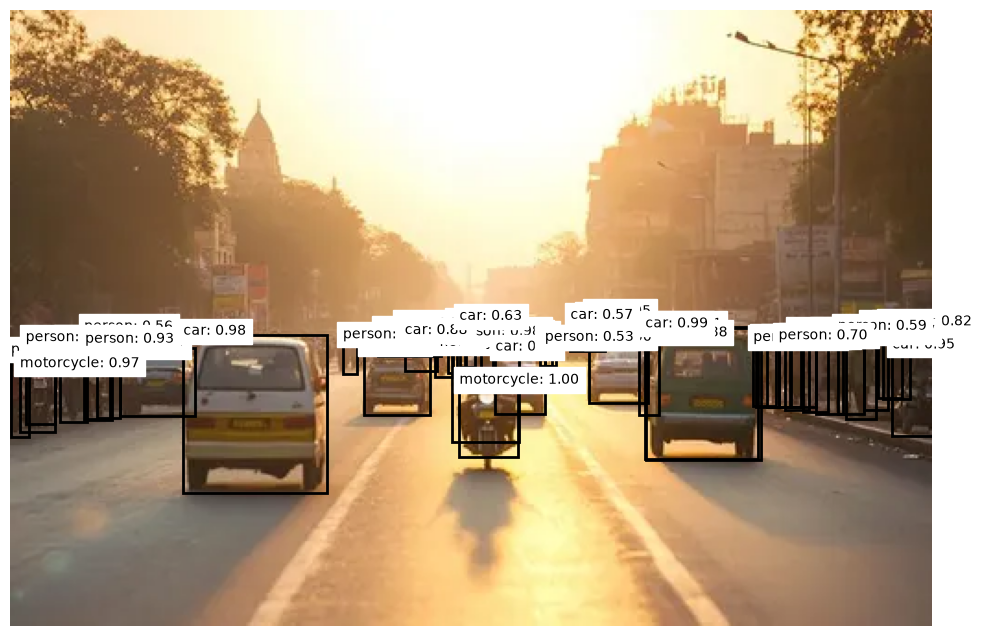

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image)

for detection in detections:
    label = detection["label"]
    score = detection["score"]
    box = detection["box"]

    xmin = box["xmin"]
    ymin = box["ymin"]
    xmax = box["xmax"]
    ymax = box["ymax"]

    rectangle = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        xmin,
        ymin,
        f"{label}: {score:.2f}",
        fontsize=10,
        backgroundcolor="white" 
    )

ax.axis("off")
plt.show()

In [27]:
print("Model:", type(model))
print("Processor:", type(processor))
print("Image:", image.size)
print("Input keys:", inputs.keys())
print("Output keys:", outputs.keys())

Model: <class 'transformers.models.detr.modeling_detr.DetrForObjectDetection'>
Processor: <class 'transformers.models.detr.image_processing_detr.DetrImageProcessor'>
Image: (500, 334)
Input keys: dict_keys(['pixel_mask', 'pixel_values'])
Output keys: odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])


In [28]:
logits = outputs.logits

print("Logits shape:", logits.shape)

Logits shape: torch.Size([1, 100, 92])


In [29]:
logits = outputs.logits[0]

print("Shape:", logits.shape)

Shape: torch.Size([100, 92])


In [30]:
query_0 = logits[0]

print("Shape:", query_0.shape)
print(query_0)

Shape: torch.Size([92])
tensor([-13.5236,   5.8233,   1.5541,   1.7588,   4.6251,  -5.1051,  -2.9710,
         -5.6383,  -0.8852,  -5.4883,  -0.2653,  -3.4110, -13.6938,  -3.9419,
         -1.9138,  -2.0328,  -5.0775,  -7.7440,  -5.8310,  -2.5038, -10.2632,
         -4.4354,  -5.1621, -13.5977,  -4.2164,  -6.3009, -13.6223,   3.1744,
         -1.2617, -13.4928, -13.8701,   3.2514,  -1.5979,  -1.4677, -10.0250,
         -2.3365,  -0.5227,  -7.5193,  -5.6539,  -4.8931,  -3.3524,  -1.4282,
         -4.0439,  -7.2787,  -2.6327, -13.4459,  -4.1418,  -3.3954,  -5.7823,
         -6.4267,  -5.8651,  -8.3651,  -4.5830, -11.2884,  -5.5899,  -7.8408,
         -6.3559,  -4.7641,  -6.3079, -11.3745,  -9.6559,  -8.9349,  -2.5183,
         -8.4523,  -2.9208,  -5.4153, -13.7082,  -3.2939, -13.7274, -13.4640,
         -8.1833, -13.2114,  -6.1236,  -5.0655,  -7.7547, -10.5080,  -8.7126,
         -0.8577, -11.1786,  -9.4628, -14.0316,  -5.3772,  -9.0397, -13.4755,
         -5.8789,  -7.3642,  -7.7848,  -

In [31]:
probabilities = torch.softmax(query_0, dim=-1)

print("Shape:", probabilities.shape)
print(probabilities)

Shape: torch.Size([92])
tensor([1.3103e-09, 3.3084e-01, 4.6292e-03, 5.6806e-03, 9.9823e-02, 5.9356e-06,
        5.0150e-05, 3.4825e-06, 4.0376e-04, 4.0462e-06, 7.5052e-04, 3.2300e-05,
        1.1052e-09, 1.8993e-05, 1.4435e-04, 1.2815e-04, 6.1018e-06, 4.2401e-07,
        2.8720e-06, 8.0018e-05, 3.4145e-08, 1.1596e-05, 5.6065e-06, 1.2166e-09,
        1.4435e-05, 1.7953e-06, 1.1870e-09, 2.3400e-02, 2.7709e-04, 1.3513e-09,
        9.2655e-10, 2.5270e-02, 1.9798e-04, 2.2551e-04, 4.3329e-08, 9.4585e-05,
        5.8021e-04, 5.3088e-07, 3.4287e-06, 7.3370e-06, 3.4248e-05, 2.3458e-04,
        1.7152e-05, 6.7524e-07, 7.0337e-05, 1.4160e-09, 1.5552e-05, 3.2807e-05,
        3.0154e-06, 1.5831e-06, 2.7758e-06, 2.2784e-07, 1.0004e-05, 1.2249e-08,
        3.6553e-06, 3.8490e-07, 1.6992e-06, 8.3476e-06, 1.7827e-06, 1.1237e-08,
        6.2669e-08, 1.2888e-07, 7.8866e-05, 2.0883e-07, 5.2733e-05, 4.3526e-06,
        1.0894e-09, 3.6311e-05, 1.0686e-09, 1.3906e-09, 2.7327e-07, 1.7903e-09,
        2.1436e-

In [32]:
print("Sum:", probabilities.sum().item())

Sum: 1.0


In [35]:
print("Number of logits:", logits.shape[-1])
print("Number of model labels:", model.config.num_labels)
print("Number of id2label entries:", len(model.config.id2label))

print("\nLast few label mappings:")

for class_id in range(
    max(0, len(model.config.id2label) - 5),
    len(model.config.id2label)
):
    print(
        class_id,
        "->",
        model.config.id2label[class_id]
    )

print("\nSpecial DETR output:")
print("Class ID 91 -> no object")

Number of logits: 92
Number of model labels: 91
Number of id2label entries: 91

Last few label mappings:
86 -> vase
87 -> scissors
88 -> teddy bear
89 -> hair drier
90 -> toothbrush

Special DETR output:
Class ID 91 -> no object


In [36]:
class_id = probabilities[:-1].argmax().item()
score = probabilities[class_id].item()

print("Class ID:", class_id)
print("Score:", score)
print("Label:", model.config.id2label[class_id])

Class ID: 1
Score: 0.3308374583721161
Label: person


In [37]:
query_probabilities = torch.softmax(
    logits,
    dim=-1
)

# DETR's final class is the special "no object" class.
object_probabilities = query_probabilities[:, :-1]

scores, class_ids = object_probabilities.max(dim=-1)

print("Number of queries:", len(scores))

for query_id in range(10):
    score = scores[query_id].item()
    class_id = class_ids[query_id].item()

    label = model.config.id2label[class_id]

    print(
        f"Query {query_id:2d}: "
        f"{label:15s} "
        f"{score:.4f}"
    )

Number of queries: 100
Query  0: person          0.3308
Query  1: person          0.5496
Query  2: truck           0.4239
Query  3: car             0.3543
Query  4: car             0.6830
Query  5: person          0.4258
Query  6: person          0.7110
Query  7: person          0.4308
Query  8: person          0.1958
Query  9: person          0.3800


In [38]:
query_id = 0

query_probs = torch.softmax(
    outputs.logits[0, query_id],
    dim=-1
)

no_object_probability = query_probs[-1].item()

print("No-object probability:", no_object_probability)

No-object probability: 0.5062518119812012


In [39]:
print("High-confidence object predictions")
print("----------------------------------")

threshold = 0.5

for query_id in range(len(scores)):
    score = scores[query_id].item()

    if score >= threshold:
        class_id = class_ids[query_id].item()
        label = model.config.id2label[class_id]

        print(
            f"Query {query_id:3d} | "
            f"{label:15s} | "
            f"{score:.3f}"
        )

High-confidence object predictions
----------------------------------
Query   1 | person          | 0.550
Query   4 | car             | 0.683
Query   6 | person          | 0.711
Query  13 | person          | 0.810
Query  15 | person          | 0.559
Query  18 | person          | 0.768
Query  20 | truck           | 0.713
Query  21 | person          | 0.654
Query  23 | car             | 0.947
Query  26 | person          | 0.765
Query  28 | car             | 0.705
Query  30 | person          | 0.863
Query  31 | motorcycle      | 0.818
Query  33 | person          | 0.841
Query  35 | car             | 0.719
Query  36 | person          | 0.819
Query  39 | car             | 0.554
Query  40 | person          | 0.781
Query  43 | car             | 0.997
Query  44 | person          | 0.962
Query  46 | person          | 0.587
Query  48 | person          | 0.945
Query  50 | car             | 0.687
Query  51 | car             | 0.946
Query  53 | car             | 0.945
Query  54 | person          | 

In [40]:
raw_boxes = outputs.pred_boxes[0]

print("Number of queries:", raw_boxes.shape[0])
print("Values per box:", raw_boxes.shape[1])

print("\nFirst 5 raw boxes:")

for query_id in range(5):
    print(
        f"Query {query_id}: "
        f"{raw_boxes[query_id].tolist()}"
    )

Number of queries: 100
Values per box: 4

First 5 raw boxes:
Query 0: [0.06264907121658325, 0.6047987937927246, 0.029202602803707123, 0.12436790019273758]
Query 1: [0.4949590861797333, 0.5530589818954468, 0.01660260371863842, 0.04946058988571167]
Query 2: [0.15899017453193665, 0.6017852425575256, 0.07839953899383545, 0.11409284174442291]
Query 3: [0.5089694857597351, 0.5201007127761841, 0.021438051015138626, 0.025662098079919815]
Query 4: [0.4565967321395874, 0.5259473323822021, 0.02123132348060608, 0.025438936427235603]


In [42]:
query_id = 4

box = raw_boxes[query_id]

print("Query:", query_id)
print("Class:", model.config.id2label[class_ids[query_id].item()])
print("Confidence:", scores[query_id].item())

print("\nRaw bounding box:")
print(box.tolist())

Query: 4
Class: car
Confidence: 0.6830475926399231

Raw bounding box:
[0.4565967321395874, 0.5259473323822021, 0.02123132348060608, 0.025438936427235603]


In [43]:
image_width, image_height = image.size

cx, cy, width, height = box.tolist()

cx_pixel = cx * image_width
cy_pixel = cy * image_height

width_pixel = width * image_width
height_pixel = height * image_height

print("Center X:", cx_pixel)
print("Center Y:", cy_pixel)
print("Width:", width_pixel)
print("Height:", height_pixel)

Center X: 228.2983660697937
Center Y: 175.66640901565552
Width: 10.61566174030304
Height: 8.496604766696692


In [44]:
xmin = cx_pixel - width_pixel / 2
ymin = cy_pixel - height_pixel / 2

xmax = cx_pixel + width_pixel / 2
ymax = cy_pixel + height_pixel / 2

print("Bounding box in pixels:")
print(
    f"xmin={xmin:.1f}, "
    f"ymin={ymin:.1f}, "
    f"xmax={xmax:.1f}, "
    f"ymax={ymax:.1f}"
)

Bounding box in pixels:
xmin=223.0, ymin=171.4, xmax=233.6, ymax=179.9


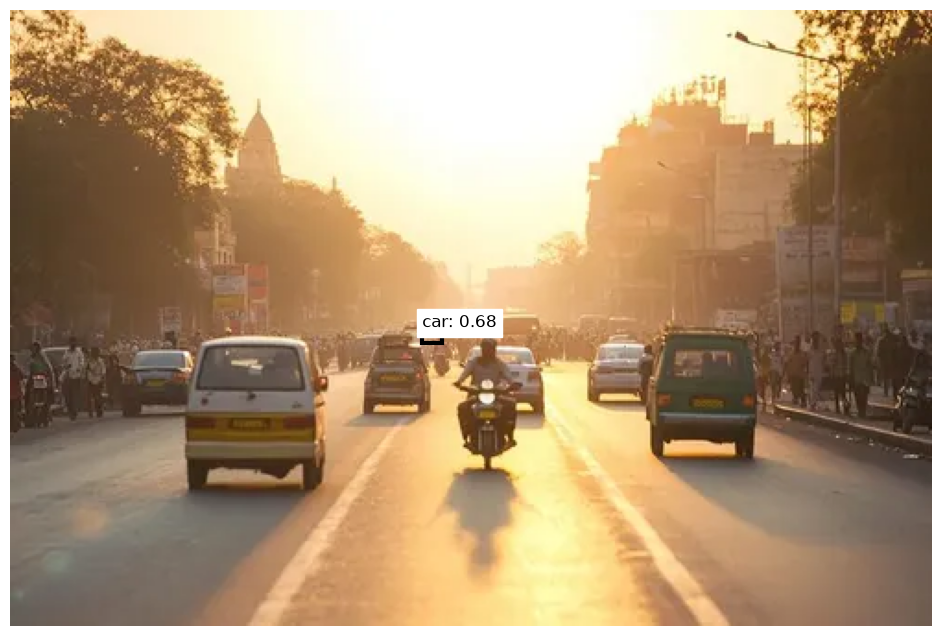

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image)

rectangle = Rectangle(
    (xmin, ymin),
    xmax - xmin,
    ymax - ymin,
    fill=False,
    linewidth=3
)

ax.add_patch(rectangle)

ax.text(
    xmin,
    ymin,
    f"{model.config.id2label[class_ids[query_id].item()]}: "
    f"{scores[query_id].item():.2f}",
    fontsize=12,
    backgroundcolor="white"
)

ax.axis("off")

plt.show()

In [46]:
# Manual bounding box
manual_box = torch.tensor([
    xmin,
    ymin,
    xmax,
    ymax
])

# Hugging Face post-processed results
hf_boxes = result["boxes"]

print("Manual box:")
print(manual_box.tolist())

print("\nHugging Face boxes:")

for i, hf_box in enumerate(hf_boxes):
    print(f"{i}: {hf_box.tolist()}")

Manual box:
[222.99053955078125, 171.41810607910156, 233.606201171875, 179.9147186279297]

Hugging Face boxes:
0: [243.3289031982422, 176.46177673339844, 251.63018798828125, 192.98162841796875]
1: [222.99053955078125, 171.41810607910156, 233.60618591308594, 179.91470336914062]
2: [237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]
3: [419.6012268066406, 178.13890075683594, 432.9241943359375, 216.2056884765625]
4: [39.66762161254883, 173.23582458496094, 54.56563949584961, 221.84933471679688]
5: [409.7339782714844, 178.51080322265625, 422.407958984375, 215.01991271972656]
6: [344.268310546875, 171.84300231933594, 406.4440612792969, 243.4425506591797]
7: [404.0029602050781, 178.7337646484375, 416.21630859375, 214.98451232910156]
8: [477.89654541015625, 183.05799865722656, 499.97882080078125, 230.21435546875]
9: [462.7656555175781, 171.01124572753906, 475.67608642578125, 216.4522705078125]
10: [238.1565704345703, 169.8872833251953, 249.96583557128906, 178.91638183593

In [47]:
print("Query 4")
print("-------")

print("Class ID:", class_ids[4].item())
print("Label:", model.config.id2label[class_ids[4].item()])
print("Score:", scores[4].item())

print("\nRaw box:")
print(raw_boxes[4].tolist())

print("\nManual pixel box:")
print([
    round(xmin, 2),
    round(ymin, 2),
    round(xmax, 2),
    round(ymax, 2)
])

Query 4
-------
Class ID: 3
Label: car
Score: 0.6830475926399231

Raw box:
[0.4565967321395874, 0.5259473323822021, 0.02123132348060608, 0.025438936427235603]

Manual pixel box:
[222.99, 171.42, 233.61, 179.91]
